# Define the Plotting Function

In [1]:
%jsroot off

In [2]:
#include <ROOT/RDataFrame.hxx>
#include <TFile.h>
#include <TH1F.h>
#include <TTree.h>
#include <iostream>

In [3]:
# include "TDatabasePDG.h"
# include "TParticlePDG.h"

In [4]:
std::unordered_map <std::string, std::string> particle_mapping_dictionary
{
    // Baryon
    {"proton","2212"}, // (uud)
    {"sigma_plus", "3222"}, // (uus)
    {"sigma_plus_plus_c", "4222"}, // (uuc)
    {"sigma_asterisk_plus_b", "5224"}, // (uub)
    {"neutron", "2112"}, // (ddu)
    {"sigma_minus", "3112"}, // (dds)
    {"xi_zero_c", "4132"}, // (ddc)
    {"sigma_minus_b", "5112"}, // (ddb)
    {"xi_zero", "3322"}, // (ssu)
    {"xi_minus", "3312"}, // (ssd)
    {"omega_0_c", "4332"}, // (ssc)
    {"omega_minus_b", "5332"}, // (ssb)
    {"xi_plus_plus_c_c", "4422"}, // (ccu)
    {"xi_plus_c_c", "4412"}, // (ccd)
    {"omega_plus_c_c", "4432"}, // (ccs)
    {"omega_plus_b_c_c", "5442"}, // (ccb)
    {"xi_0_b_b", "5522"}, // (bbu)
    {"xi_minus_b_b", "5512"}, // (bbd)
    {"omega_minus_b_b", "5532"}, // (bbs)
    {"omega_0_b_b_c", "5542"}, // (bbc)
    // Meson
    {"pion_+", "211"}, // (u -d)
    {"pion_-", "-211"}, // (d -u)
    {"pion_0", "111"}, // (u -u) or (d -d)
    {"pion_bar_0", "-111"}, // (u -u) or (d -d)
    {"D_0", "421"}, // (c -u)
    {"D_bar_0", "-421"}, // (u -c)
    {"D_+", "411"}, // (c -d)
    {"D_-", "-411"}, // (d -c)
    {"eta", "221"}, // (c -c)
    {"K_0", "311"}, // (d -s)
    {"K_bar_0", "-311"}, // (s -d)
    {"K_+", "321"}, // (u -s)
    {"K_-", "-321"}, // (s -u)
    {"D_+_s", "431"}, // (c -s)
    {"D_-_s", "-431"}, // (s -c)
    {"eta_c", "441"}, // (c -c)
    {"B_0", "511"}, // (d -b)
    {"B_bar_0", "-511"}, // (b -d)
    {"B_+", "521"}, // (u -b)
    {"B_-", "-521"}, // (b -u)
    {"B_0_s", "531"}, // (s -b)
    {"B_bar_0_s", "-531"}, // (b -s)
    {"B_+_c", "541"}, // (c -b)
    {"B_-_c", "-541"}, // (b -c)
    {"eta_b", "551"} // (b -b)
};

In [5]:
std::pair<double, double> get_particle_mass(const std::string& filename)
{
    // std::cout << "The Filename is:" << filename.c_str() << std::endl;

    std::string key1 = "Simulation_";
    std::string key2 = "_and_";
    std::string key3 = ".root";

    size_t startA = filename.find(key1);
    size_t startB = filename.find(key2);
    size_t endB   = filename.find(key3);

    std::string idA_input, idB_input;

    if (startA != std::string::npos &&
        startB != std::string::npos &&
        endB   != std::string::npos) 
    {

        startA += key1.length();
        idA_input = filename.substr(startA, startB - startA);

        startB += key2.length();
        idB_input = filename.substr(startB, endB - startB);
    }
    else 
    {
        throw std::runtime_error("Filename format invalid");
    }

    auto idA_str = particle_mapping_dictionary.find(idA_input);
    auto idB_str = particle_mapping_dictionary.find(idB_input);
    
    int idA = std::stoi(idA_str->second);
    int idB = std::stoi(idB_str->second);

    // std::cout << "The first particle is:" << idA_input << " With Code: " << idA << std::endl;
    // std::cout << "The second particle is:" << idB_input << " With Code: " << idB << std::endl;

    TDatabasePDG* db = TDatabasePDG::Instance();
    
    TParticlePDG* particle_1 = db->GetParticle(idA);
    TParticlePDG* particle_2 = db->GetParticle(idB);

    double mass1 = particle_1->Mass();
    double mass2 = particle_2->Mass();

    std::cout << "Mass of 1st particle = " << mass1 << " GeV/c^2" << std::endl;
    std::cout << "Mass of 2nd particle = " << mass2 << " GeV/c^2" << std::endl;

    return std::make_pair(mass1, mass2);
}

In [6]:
double M2_moller_theoretical_yukawa(double theta, double g, double m, double E) {
    if (std::sin(theta / 2) < 1e-6) {  // Check for small angle (threshold 1e-6)
        return 0.0;  // Avoid division by zero or returning NaN
    }
    
    double momentum_transfer = 2.0 * E * E * (1 - std::cos(theta));
    return (g * g / 4.0) * (1.0 / std::pow(std::sin(theta / 2), 4)) / (m * m + momentum_transfer);
}

In [7]:
double total_cross_section_moller_yukawa_theoretical(double g, double m, double E, double theta_min, double theta_max, int N) {
    double h = (theta_max - theta_min) / N;  // step size
    double sum = 0.0;

    for (int i = 0; i <= N; ++i) {
        double theta = theta_min + i * h;
        double weight;

        // Simpson's rule weights
        if (i == 0 || i == N)
            weight = 1.0;
        else if (i % 2 == 0)
            weight = 2.0;
        else
            weight = 4.0;

        // Calculate the differential cross section
        double dSigma_dOmega = M2_moller_theoretical_yukawa(theta, g, m, E);
        
        // Multiply by sin(θ) (for full solid angle integration)
        sum += weight * dSigma_dOmega * std::sin(theta);
    }

    // Multiply by 2π and normalize by the step size
    return 2.0 * M_PI * (h / 3.0) * sum;
}

In [8]:
double M2_compton_theoretical_yukawa(double theta, double g, double m, double E) {
    if (std::sin(theta) < 1e-6) {  // Check for small angle (threshold 1e-6)
        return 0.0;  // Avoid division by zero or returning NaN
    }

    double momentum_transfer = 2.0 * E * E * (1 - std::cos(theta));
    return (g * g / 4.0) * (1.0 + std::pow(std::cos(theta), 2)) / (std::sin(theta) * std::sin(theta) * (m * m + momentum_transfer));
}

In [9]:
double total_cross_section_compton_yukawa_theoretical(double g, double m, double E, double theta_min, double theta_max, int N) {
    double h = (theta_max - theta_min) / N;  // step size
    double sum = 0.0;

    for (int i = 0; i <= N; ++i) {
        double theta = theta_min + i * h;
        double weight;

        // Simpson's rule weights
        if (i == 0 || i == N)
            weight = 1.0;
        else if (i % 2 == 0)
            weight = 2.0;
        else
            weight = 4.0;

        // Calculate the differential cross section
        double dSigma_dOmega = M2_compton_theoretical_yukawa(theta, g, m, E);
        
        // Multiply by sin(θ) (for full solid angle integration)
        sum += weight * dSigma_dOmega * std::sin(theta);
    }

    // Multiply by 2π and normalize by the step size
    return 2.0 * M_PI * (h / 3.0) * sum;
}

In [10]:
void read_histogram(const std::string& filename)
{
    std::cout << "-------------------------------------" << std::endl;
    
    TFile *file = TFile::Open( gSystem->ExpandPathName(filename.c_str()) );

    std::cout << "reading the file:" << gSystem->ExpandPathName(filename.c_str()) << std::endl;

    if (!file || file->IsZombie())
    {
        std::cerr << "Failed to open ROOT file" << std::endl;
        return;
    }

    std::cout << "successfully opened the file" << std::endl;

    TTree *tree = (TTree*)file->Get("tree");

    if (!tree)
    {
        std::cerr << "Tree not found!" << std::endl;
        return;
    }

    std::cout << "successfully opened the tree" << std::endl;

    std::cout << "Tree has " << tree->GetEntries() << " entries." << std::endl;

    std::cout << "-------------------------------------" << std::endl;

    std::pair<double, double> masses = get_particle_mass(filename.c_str());

    int id, event, size, no;
    double px1, py1, pz1;
    double px2, py2, pz2;
    double m1, m2;
    tree->SetBranchAddress("size", &size);
    tree->SetBranchAddress("m1", &m1);
    tree->SetBranchAddress("px1", &px1);
    tree->SetBranchAddress("py1", &py1);
    tree->SetBranchAddress("pz1", &pz1);
    tree->SetBranchAddress("m2", &m2);
    tree->SetBranchAddress("px2", &px2);
    tree->SetBranchAddress("py2", &py2);
    tree->SetBranchAddress("pz2", &pz2);

    TH1F *hist_m1 = new TH1F("Mass 1 Histogram", "Histogram of Mass 1", 100, 0, 100);
    TH1F *hist_mom_x1 = new TH1F("X Momentum 1 Histogram", "Histogram of momentum 1 in x", 100, -10, 10);
    TH1F *hist_mom_y1 = new TH1F("Y Momentum 1 Histogram", "Histogram of momentum 1 in y", 100, -10, 10);
    TH1F *hist_mom_z1 = new TH1F("Z Momentum 1 Histogram", "Histogram of momentum 1 in z", 100, -100, 100);
    TH1F *hist_E1 = new TH1F("Energy 1 Histogram", "Histogram of Energy 1", 100, 0, 100);

    TH1F *hist_m2 = new TH1F("Mass 2 Histogram", "Histogram of Mass 2", 100, 0, 100);
    TH1F *hist_mom_x2 = new TH1F("X Momentum 2 Histogram", "Histogram of momentum 2 in x", 100, -10, 10);
    TH1F *hist_mom_y2 = new TH1F("Y Momentum 2 Histogram", "Histogram of momentum 2 in y", 100, -10, 10);
    TH1F *hist_mom_z2 = new TH1F("Z Momentum 2 Histogram", "Histogram of momentum 2 in z", 100, -100, 100);
    TH1F *hist_E2 = new TH1F("Energy 2 Histogram", "Histogram of Energy 2", 100, 0, 100);

    TH1F *hist_s = new TH1F("Invariant Mass Histogram", "Histogram of Invariant Mass", 10, -100, 100);
    TH1F *hist_sqrt_s = new TH1F("Center-of-Mass Energy Histogram", "Histogram of Center-of-Mass Energy", 10, -100, 100);

    Long64_t nEntries = tree->GetEntries();

    // Define √s binning
    double sqrt_s_min = 50.0;   // GeV
    double sqrt_s_max = 200.0;  // GeV
    int nBins = 10;
    double binWidth = (sqrt_s_max - sqrt_s_min) / nBins;
    
    // Arrays to count events
    std::vector<int> counts(nBins, 0);
    std::vector<int> totals(nBins, 0);
    
    for (Long64_t i = 0; i < nEntries; ++i)
    {
        tree->GetEntry(i);

        hist_m1->Fill(m1);
        hist_mom_x1->Fill(px1);
        hist_mom_y1->Fill(py1);
        hist_mom_z1->Fill(pz1);

        hist_m2->Fill(m2);
        hist_mom_x2->Fill(px2);
        hist_mom_y2->Fill(py2);
        hist_mom_z2->Fill(pz2);

        double E1 = sqrt(pow(px1, 2) + pow(py1, 2) + pow(pz1, 2) + pow(m1, 2));
        hist_E1->Fill(E1);

        double E2 = sqrt(pow(px2, 2) + pow(py2, 2) + pow(pz2, 2) + pow(m2, 2));
        hist_E2->Fill(E2);

        double s = (E1 + E2)*(E1 + E2) - ((px1 + px2)*(px1 + px2) + (py1 + py2)*(py1 + py2) + (pz1 + pz2)*(pz1 + pz2));
        double sqrt_s = sqrt(s);

        int bin = int((sqrt_s - sqrt_s_min) / binWidth);
        if(bin < 0 || bin >= nBins) continue;

        totals[bin]++;

        double dot = px1*px2 + py1*py2 + pz1*pz2;
        if(dot > 1.0) counts[bin]++;
    }

    std::cout << "successfully filled the histogram with the tree values" << std::endl;
    
    TGraph *experimental_results_graph = new TGraph();
    for(int i = 0; i < nBins; ++i)
    {
        if(totals[i] == 0) continue;  // avoid division by zero
    
        double efficiency = double(counts[i]) / totals[i];
        double sigma = 100.0 * efficiency;  // use your scale or luminosity if known
    
        double bin_center = sqrt_s_min + (i + 0.5)*binWidth;
        experimental_results_graph->SetPoint(i, bin_center, sigma);
    }
    
    experimental_results_graph->SetMarkerStyle(21);
    experimental_results_graph->SetMarkerSize(1.5);
    experimental_results_graph->SetTitle("Cross Section vs sqrt(s); sqrt(s) [GeV]; Sigma [pb]");

    std::cout << "successfully computed the cross sections" << std::endl;

    std::cout << "-------------------------------------" << std::endl;

    double theoretical_g = 1.0 / 137.0;
    double theoretical_m = 0.511;
    double theoretical_E = 10.0;

    if (filename.find("/Moller_like/") != std::string::npos) 
    {
        std::cout << "Moller-like Scattering" << std::endl;
    }
    else if (filename.find("/Compton_like/") != std::string::npos) 
    {
        std::cout << "Compton-like Scattering" << std::endl;
    }
    else 
    {
        std::cout << "Unknown Scattering Type" << std::endl;
    }

    TCanvas *canv = new TCanvas(filename.c_str(), "Canvas Title", 800, 600);

    experimental_results_graph->Draw();

    if (filename.find("/Moller_like/") != std::string::npos) 
    {
        std::cout << "Moller-like Scattering Plot" << std::endl;
    }
    else if (filename.find("/Compton_like/") != std::string::npos) 
    {
        std::cout << "Compton-like Scattering Plot" << std::endl;
    }
    else 
    {
        std::cout << "Error, can't plot an unknown scattering type" << std::endl;
    }

    canv->Update();

    std::cout << "-------------------------------------" << std::endl;
}

# Moller like

$p^0$

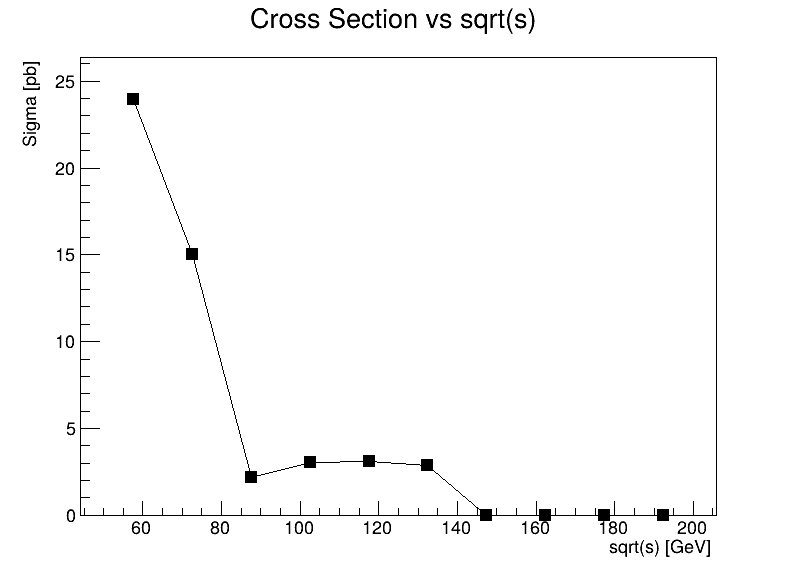

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_proton_and_proton.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.938272 GeV/c^2
Mass of 2nd particle = 0.938272 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [11]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_proton_and_proton.root");

$\Sigma^+$

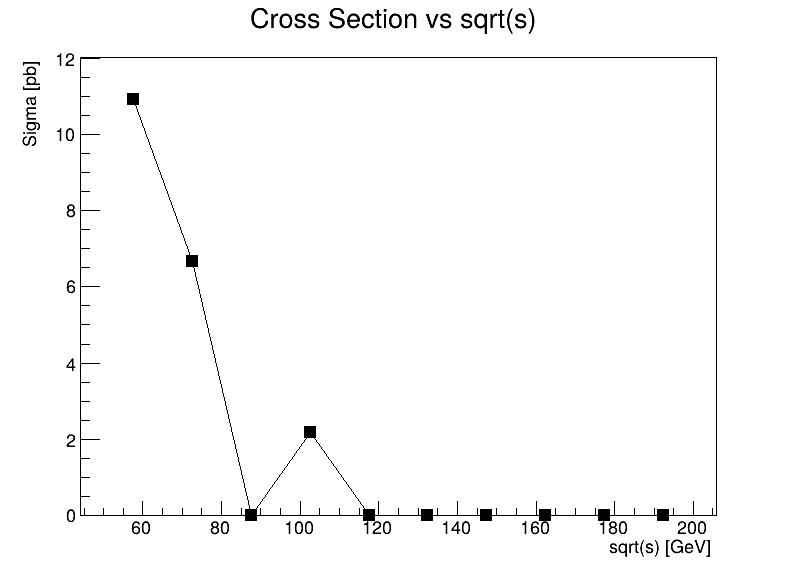

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_plus_and_sigma_plus.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.18937 GeV/c^2
Mass of 2nd particle = 1.18937 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [12]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_plus_and_sigma_plus.root");

$\Sigma^{++}_c$

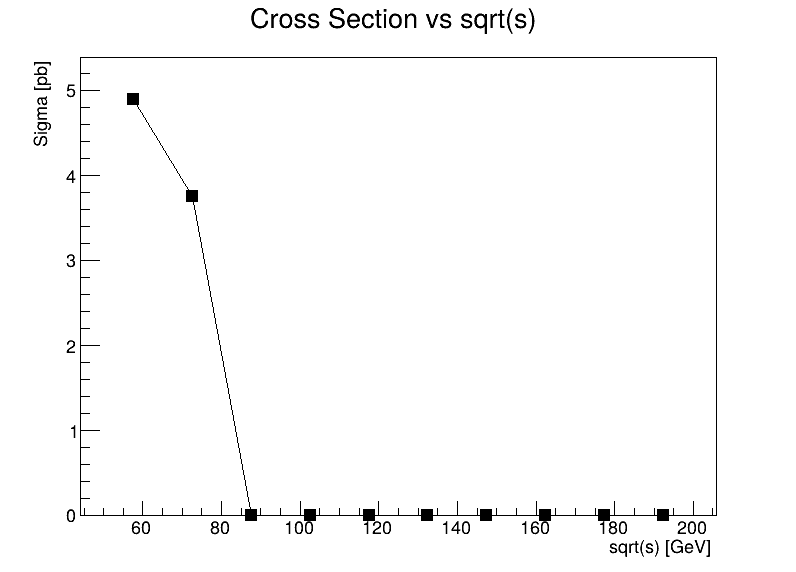

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_plus_plus_c_and_sigma_plus_plus_c.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.45397 GeV/c^2
Mass of 2nd particle = 2.45397 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [13]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_plus_plus_c_and_sigma_plus_plus_c.root");

$\Sigma^{*+}_b$

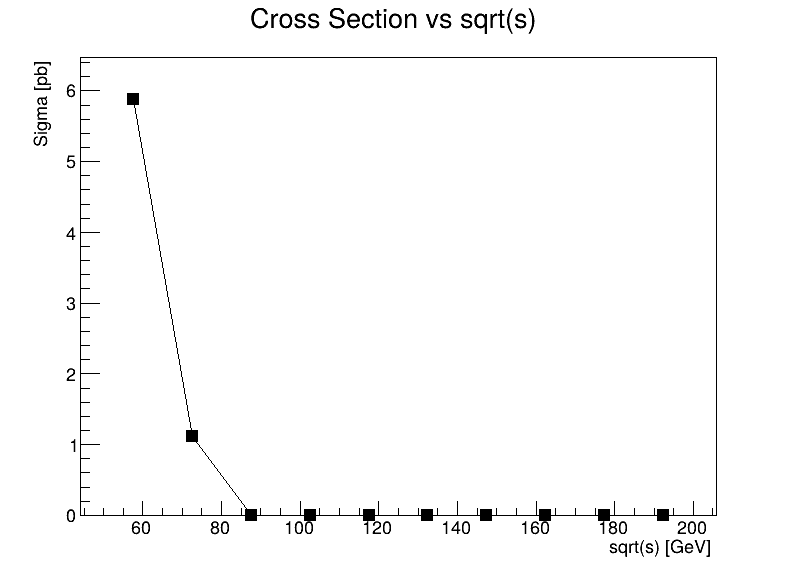

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_asterisk_plus_b_and_sigma_asterisk_plus_b.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.83032 GeV/c^2
Mass of 2nd particle = 5.83032 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [14]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_asterisk_plus_b_and_sigma_asterisk_plus_b.root");

$n^0$

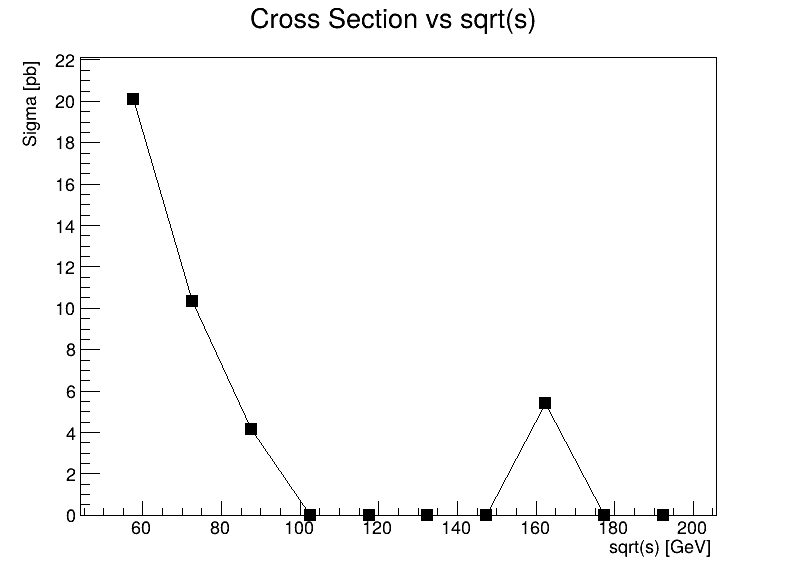

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_neutron_and_neutron.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.939565 GeV/c^2
Mass of 2nd particle = 0.939565 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [15]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_neutron_and_neutron.root");

$\Sigma^-$

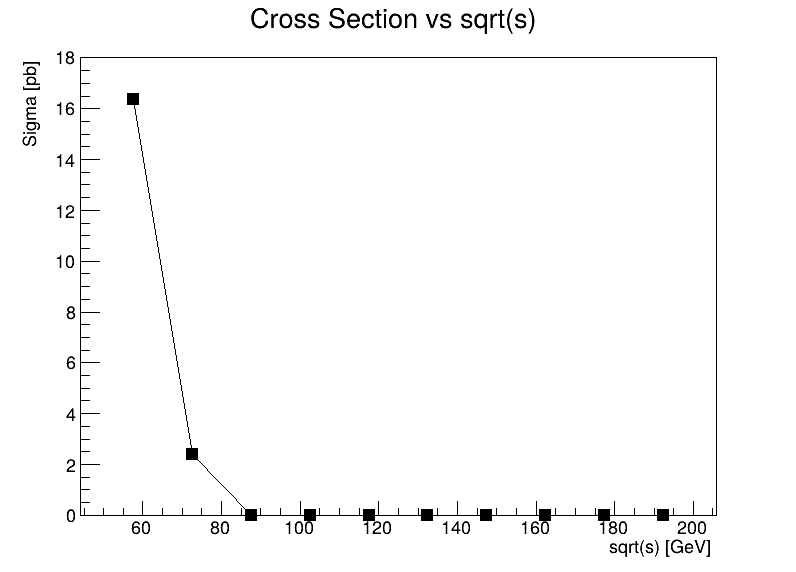

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_minus_and_sigma_minus.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.19745 GeV/c^2
Mass of 2nd particle = 1.19745 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [16]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_minus_and_sigma_minus.root");

$\Xi^{0}_c$

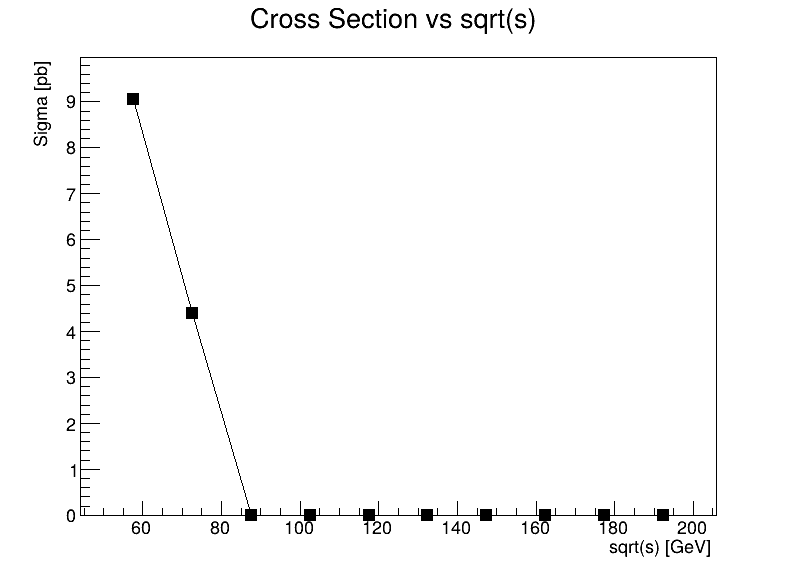

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_zero_c_and_xi_zero_c.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.47044 GeV/c^2
Mass of 2nd particle = 2.47044 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [17]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_zero_c_and_xi_zero_c.root");

$\Sigma^{-}_b$

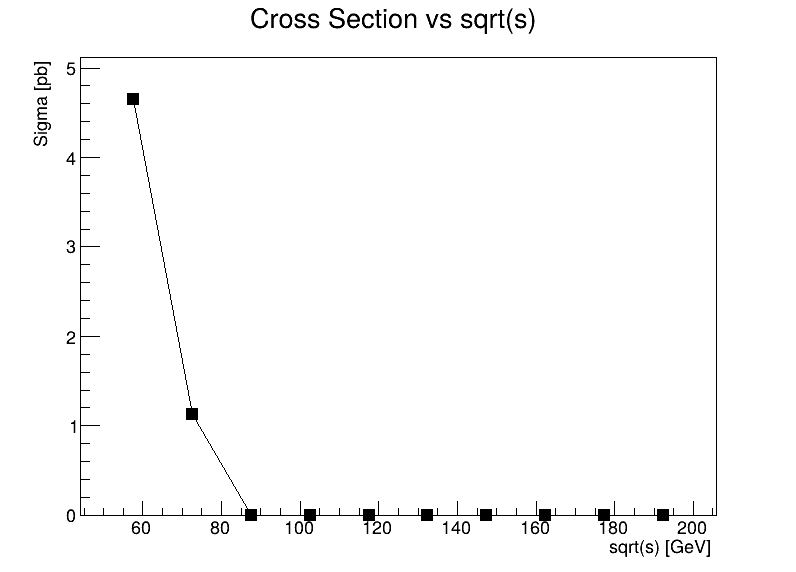

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_minus_b_and_sigma_minus_b.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.81564 GeV/c^2
Mass of 2nd particle = 5.81564 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [18]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_sigma_minus_b_and_sigma_minus_b.root");

$\Xi^0$

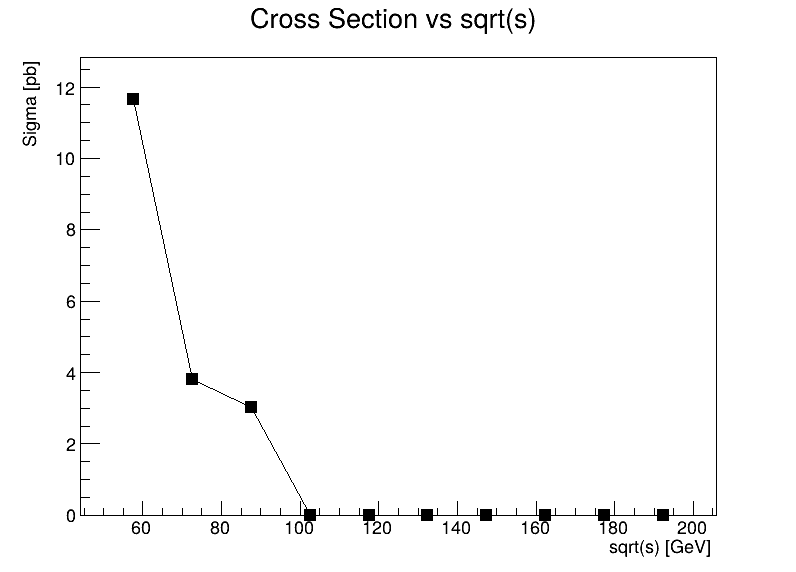

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_zero_and_xi_zero.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.31486 GeV/c^2
Mass of 2nd particle = 1.31486 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [19]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_zero_and_xi_zero.root");

$\Xi^-$

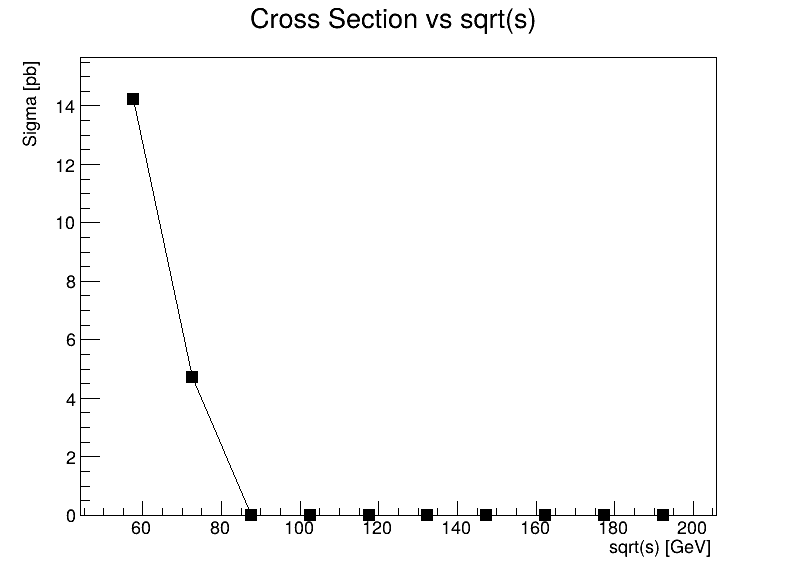

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_minus_and_xi_minus.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.32171 GeV/c^2
Mass of 2nd particle = 1.32171 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [20]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_xi_minus_and_xi_minus.root");

$\Omega^{0}_c$

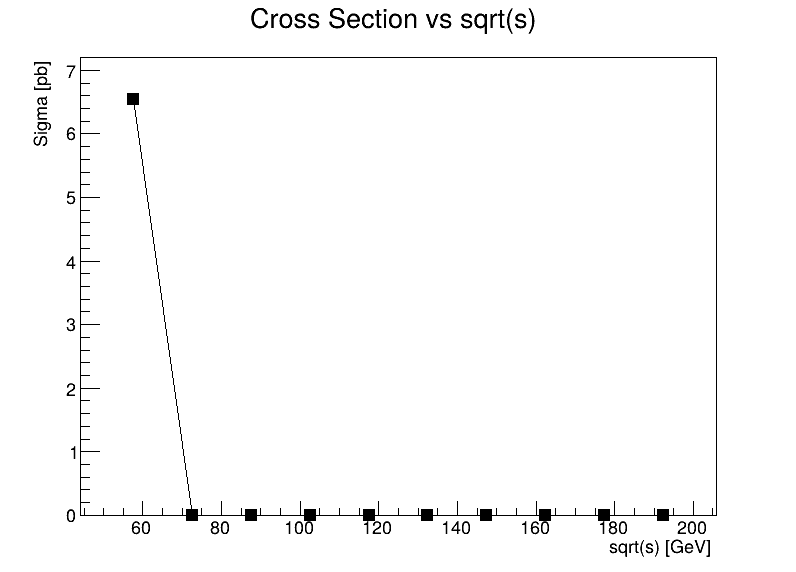

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_omega_0_c_and_omega_0_c.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.6952 GeV/c^2
Mass of 2nd particle = 2.6952 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [21]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_omega_0_c_and_omega_0_c.root");

$\Omega^{-}_b$

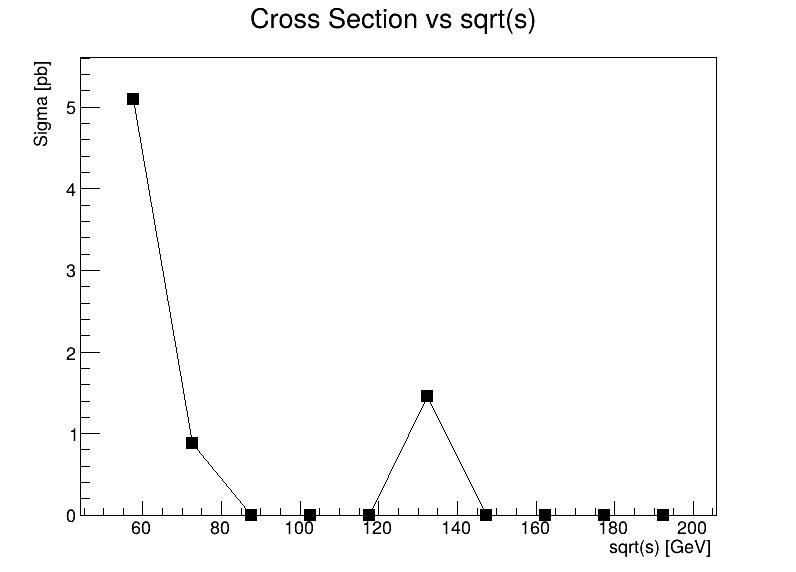

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_omega_minus_b_and_omega_minus_b.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 6.0452 GeV/c^2
Mass of 2nd particle = 6.0452 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Moller-like Scattering
Moller-like Scattering Plot
-------------------------------------


In [22]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Moller_like/Simulation_omega_minus_b_and_omega_minus_b.root");

# Compton like

$p^+ + \pi^0$

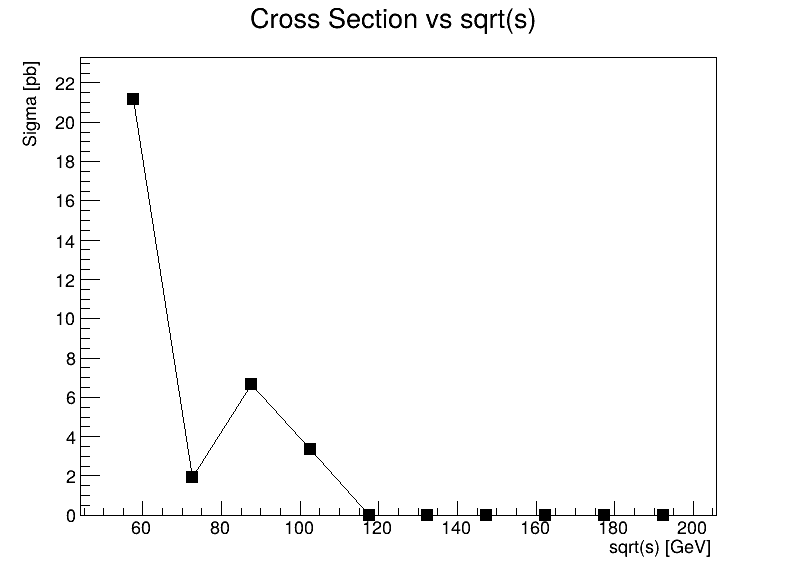

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.938272 GeV/c^2
Mass of 2nd particle = 0.134977 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [23]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_0.root");

$p^+ + \pi^+$

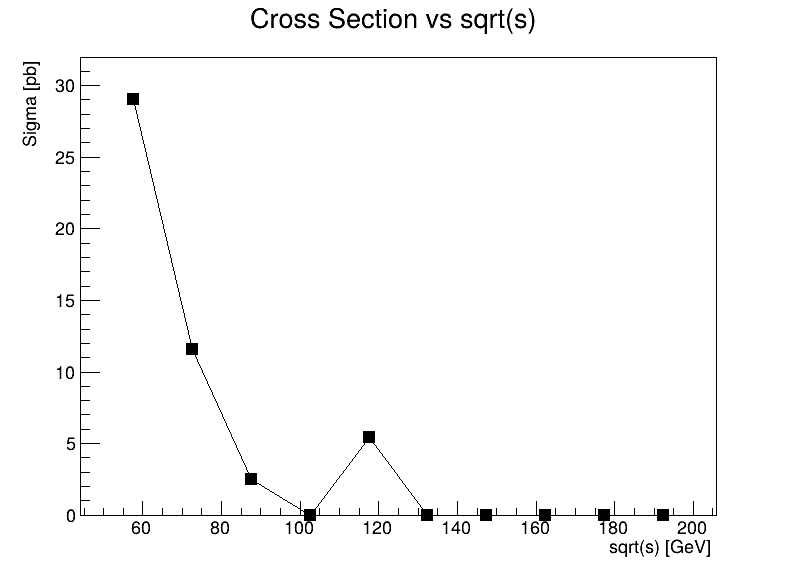

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.938272 GeV/c^2
Mass of 2nd particle = 0.13957 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [24]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_+.root");

$p^+ + \pi^-$

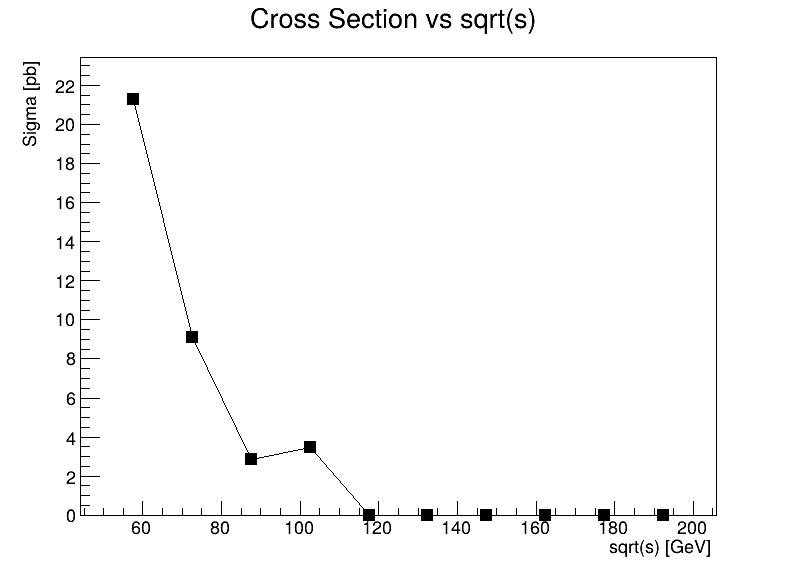

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.938272 GeV/c^2
Mass of 2nd particle = 0.13957 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [25]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_proton_and_pion_-.root");

$\Sigma^+ + \pi^0$

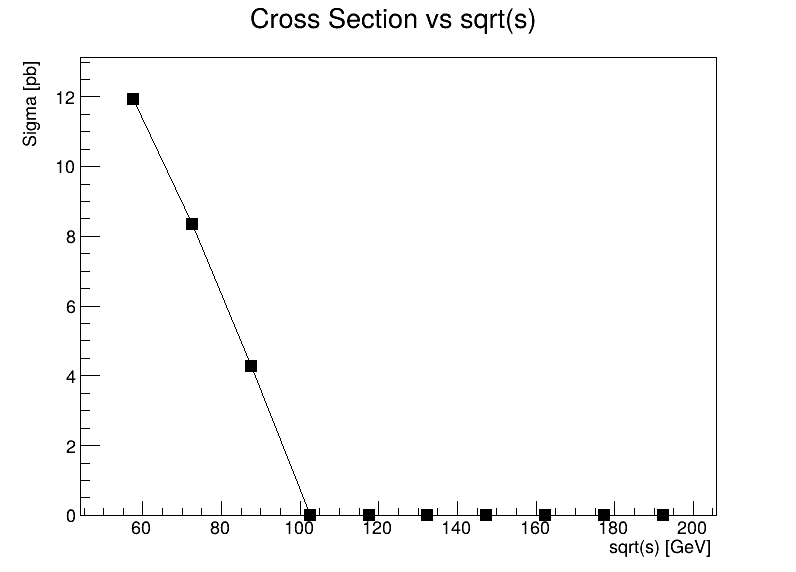

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_pion_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.18937 GeV/c^2
Mass of 2nd particle = 0.134977 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [26]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_pion_0.root");

$\Sigma^+ + K^+$

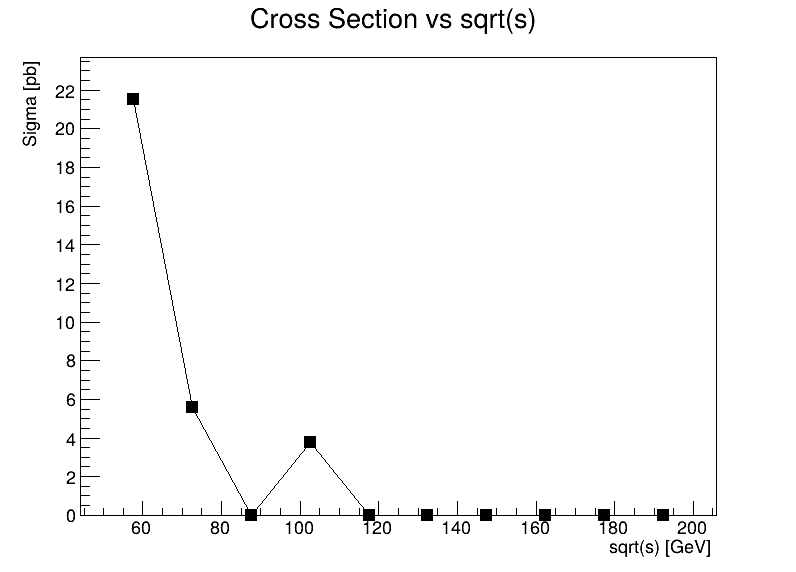

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_K_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.18937 GeV/c^2
Mass of 2nd particle = 0.493677 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [27]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_K_+.root");

$\Sigma^+ + K^-$

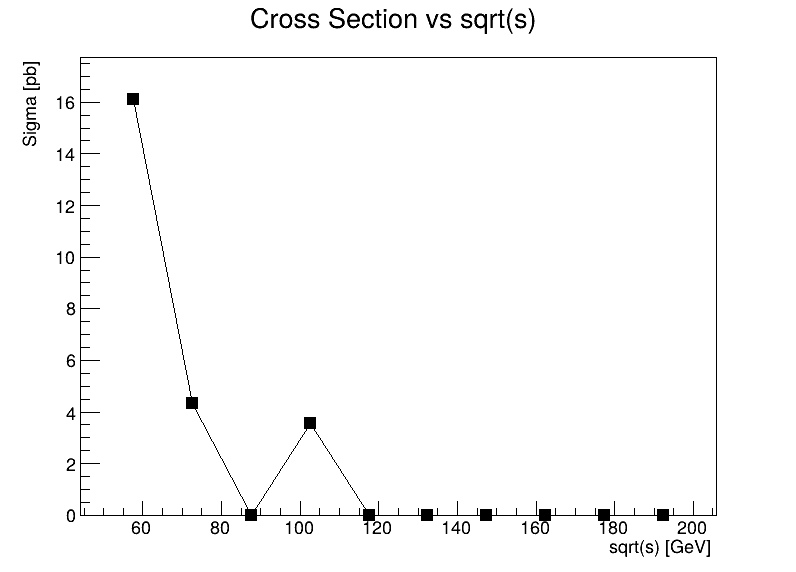

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_K_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.18937 GeV/c^2
Mass of 2nd particle = 0.493677 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [28]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_and_K_-.root");

$\Sigma^{++}_c + \pi^{0}$

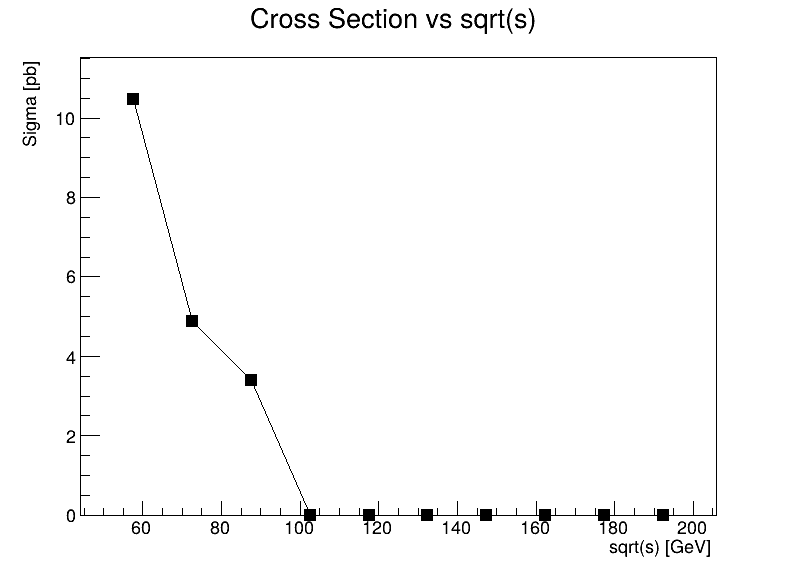

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_pion_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.45397 GeV/c^2
Mass of 2nd particle = 0.134977 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [29]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_pion_0.root");

$\Sigma^{++}_c + D^{0}$

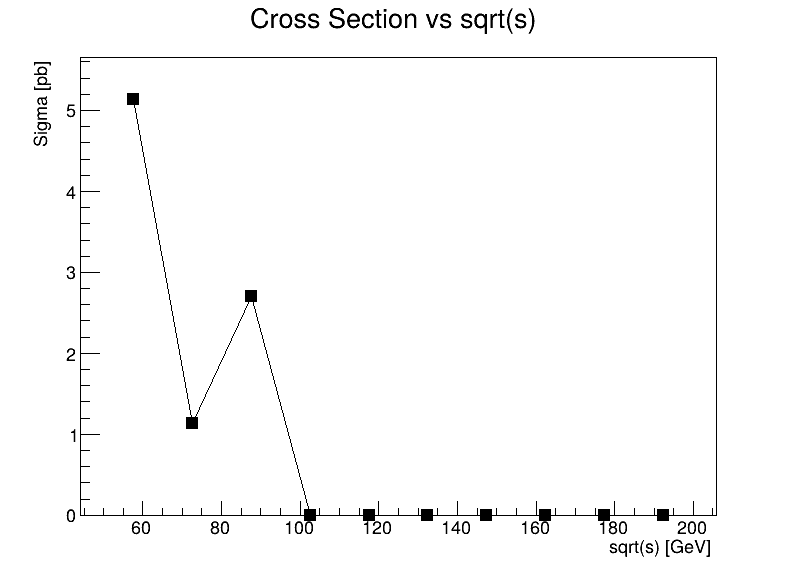

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_D_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.45397 GeV/c^2
Mass of 2nd particle = 1.86484 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [30]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_D_0.root");

$\Sigma^{++}_c + \bar{D}^{0}$

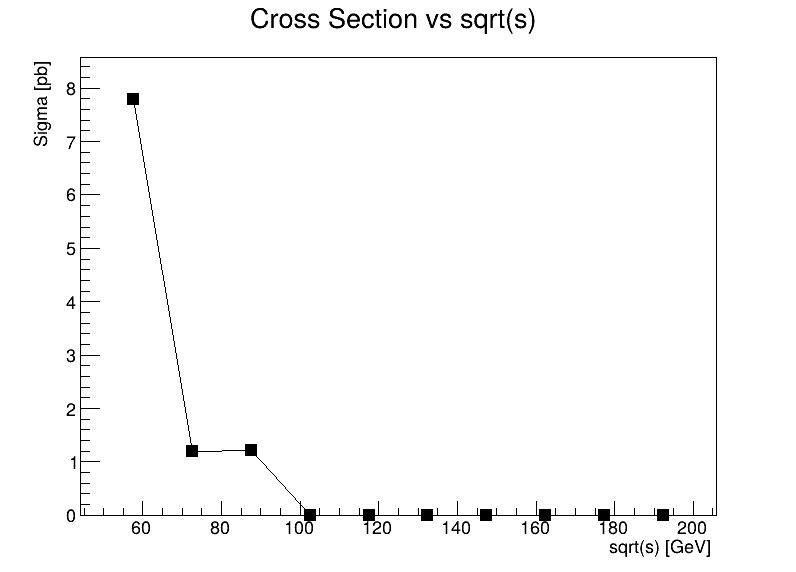

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_D_bar_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.45397 GeV/c^2
Mass of 2nd particle = 1.86484 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [31]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_plus_plus_c_and_D_bar_0.root");

$\Sigma^{*+}_b + \pi^0$

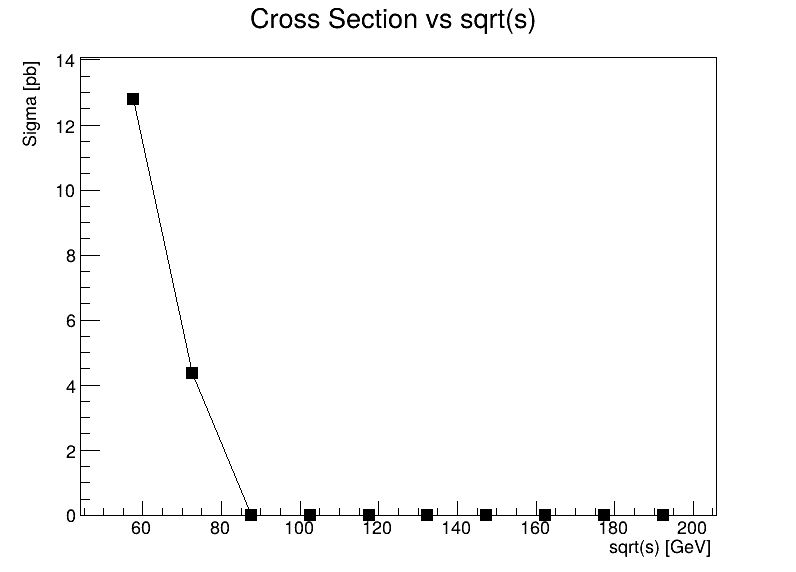

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_pion_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.83032 GeV/c^2
Mass of 2nd particle = 0.134977 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [32]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_pion_0.root");

$\Sigma^{*+}_b + B^+$

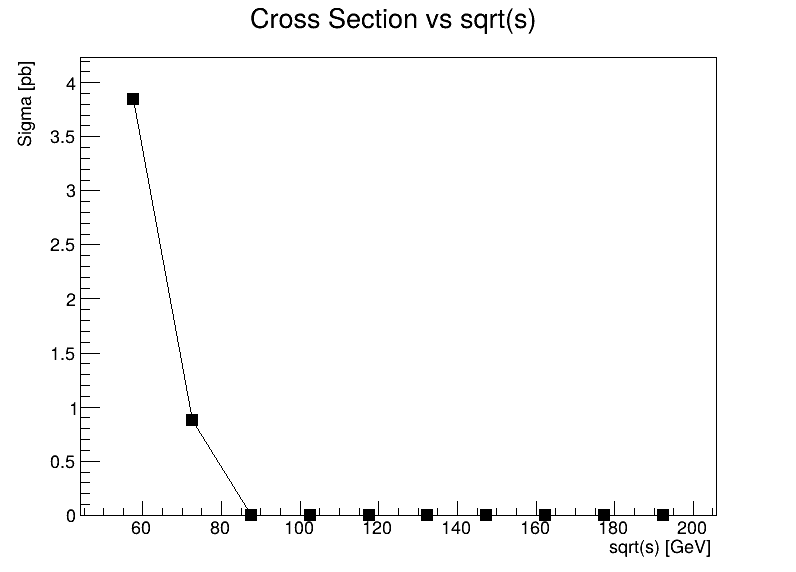

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_B_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.83032 GeV/c^2
Mass of 2nd particle = 5.27934 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [33]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_B_+.root");

$\Sigma^{*+}_b + B^-$

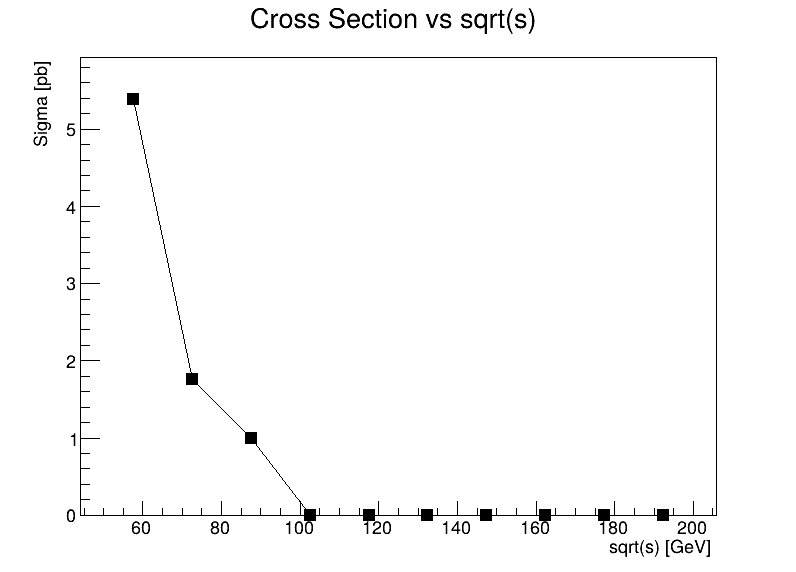

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_B_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.83032 GeV/c^2
Mass of 2nd particle = 5.27934 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [34]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_asterisk_plus_b_and_B_-.root");

$n^0 + \pi^-$

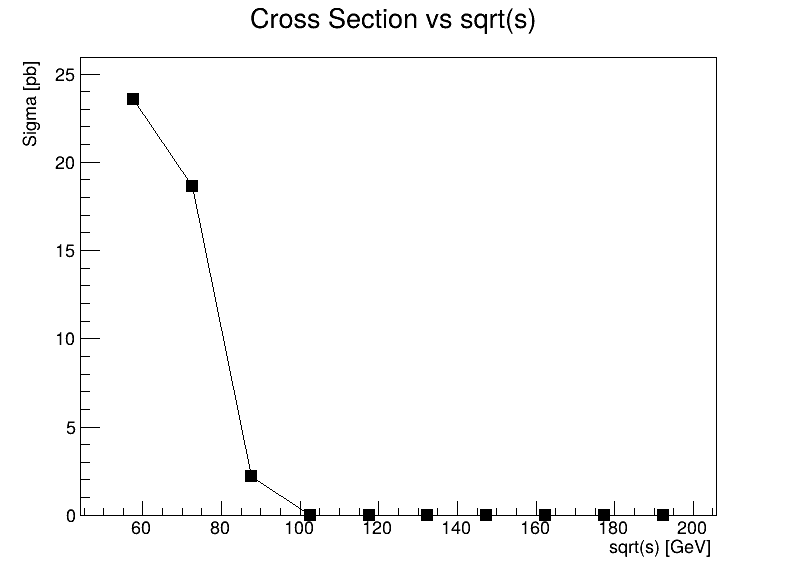

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_neutron_and_pion_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.939565 GeV/c^2
Mass of 2nd particle = 0.13957 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [35]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_neutron_and_pion_-.root");

$n^0 + \pi^+$

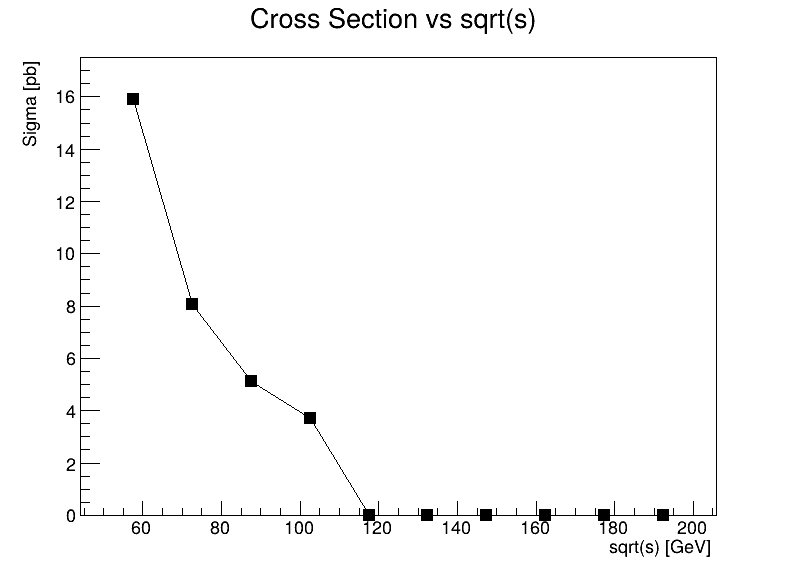

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_neutron_and_pion_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 0.939565 GeV/c^2
Mass of 2nd particle = 0.13957 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [36]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_neutron_and_pion_+.root");

$\Sigma^- + K^{0}$

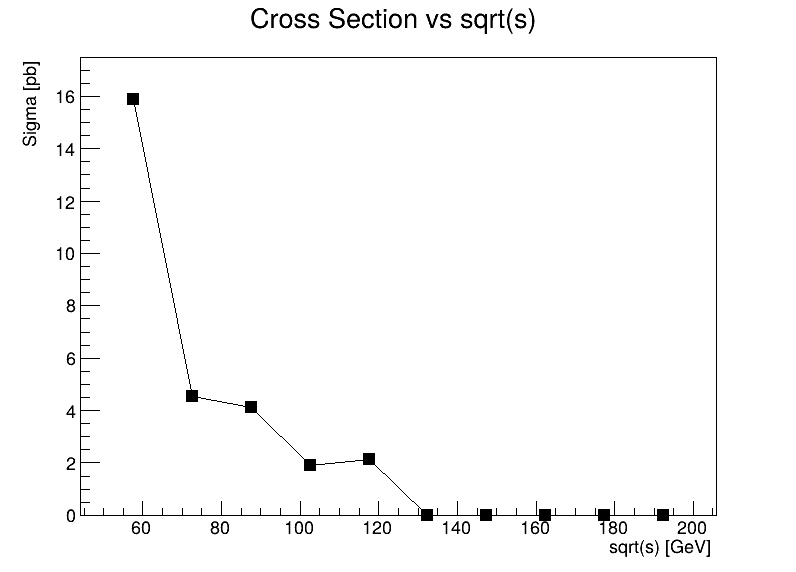

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_and_K_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.19745 GeV/c^2
Mass of 2nd particle = 0.497611 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [37]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_and_K_0.root");

$\Sigma^- + \bar{K}^{0}$

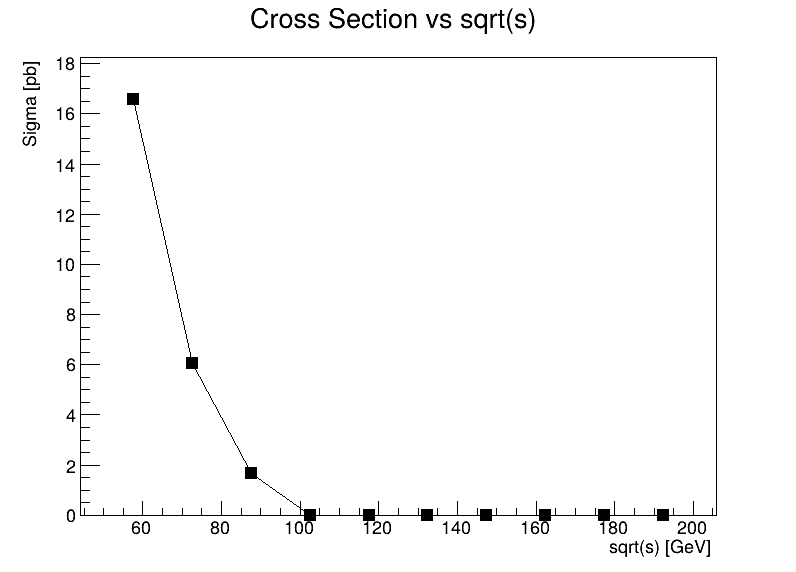

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_and_K_bar_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.19745 GeV/c^2
Mass of 2nd particle = 0.497611 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [38]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_and_K_bar_0.root");

$\Xi^{0}_c + D^-$

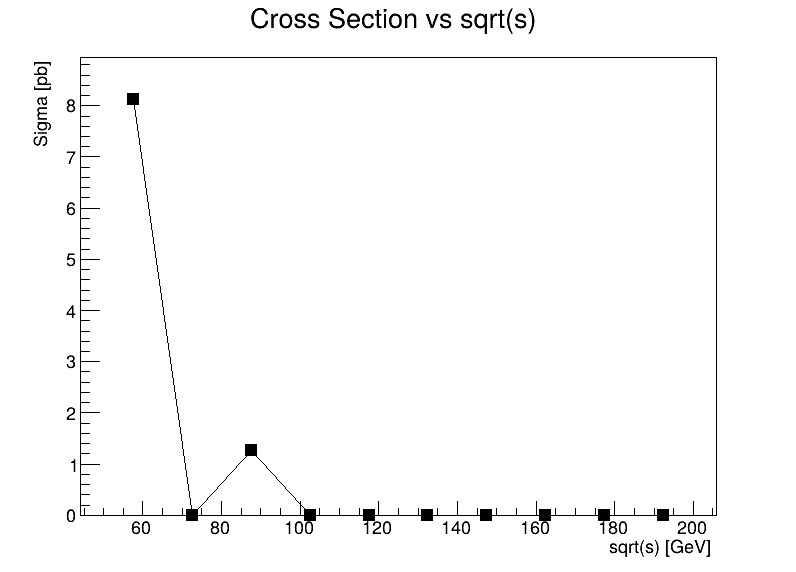

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_c_and_D_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.47044 GeV/c^2
Mass of 2nd particle = 1.86966 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [39]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_c_and_D_-.root");

$\Xi^{0}_c + D^+$

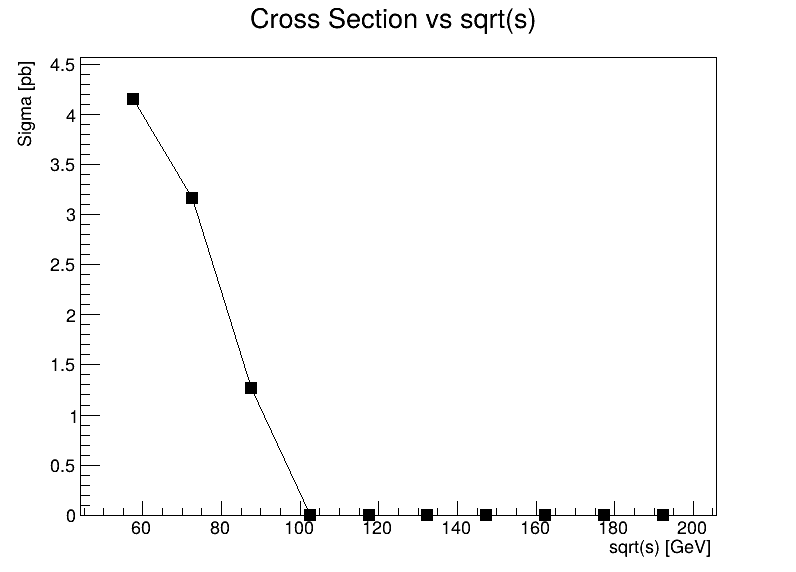

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_c_and_D_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.47044 GeV/c^2
Mass of 2nd particle = 1.86966 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [40]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_c_and_D_+.root");

$\Sigma^{-}_{b} + B^{0}$

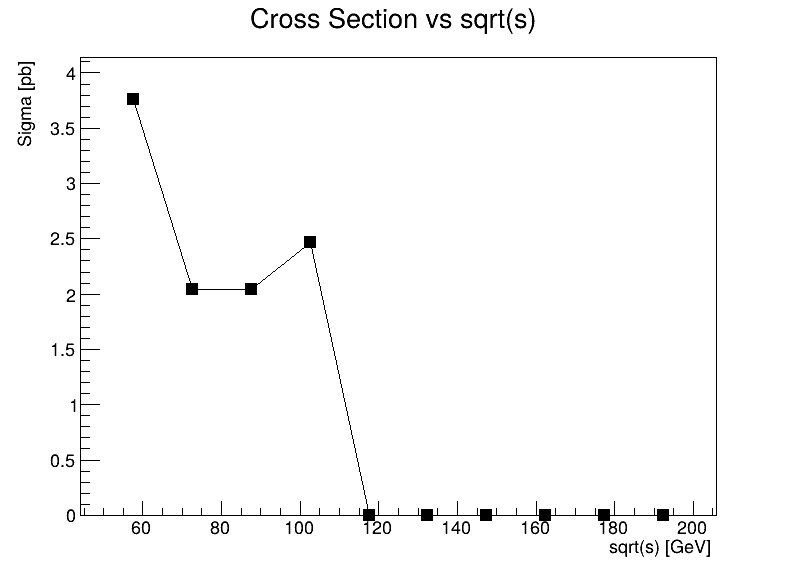

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_b_and_B_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.81564 GeV/c^2
Mass of 2nd particle = 5.27966 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [41]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_b_and_B_0.root");

$\Sigma^{-}_{b} + \bar{B}^{0}$

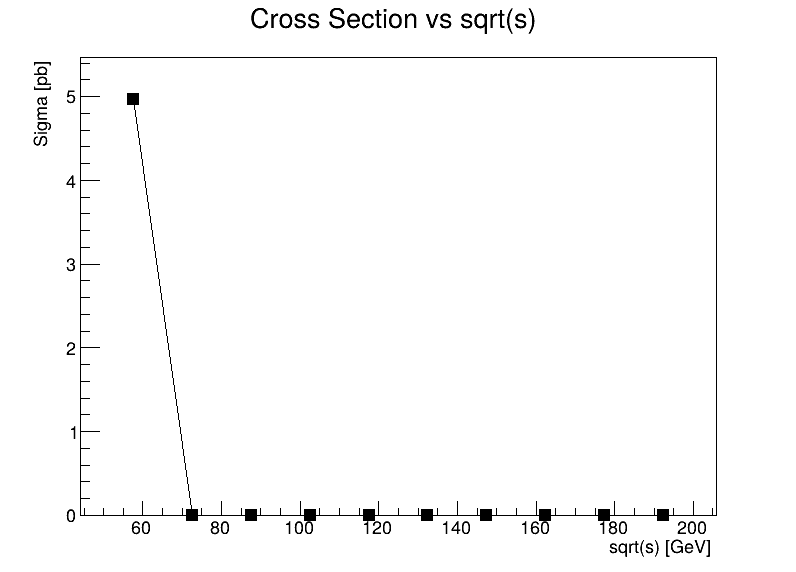

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_b_and_B_bar_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 5.81564 GeV/c^2
Mass of 2nd particle = 5.27966 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [42]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_sigma_minus_b_and_B_bar_0.root");

$\Xi^0 + \eta$

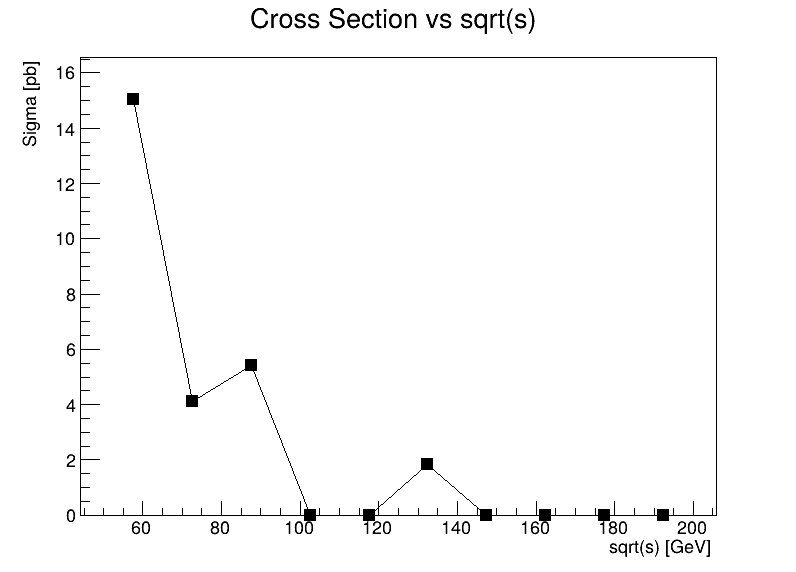

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_eta.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.31486 GeV/c^2
Mass of 2nd particle = 0.547862 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [43]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_eta.root");

$\Xi^0 + K^-$

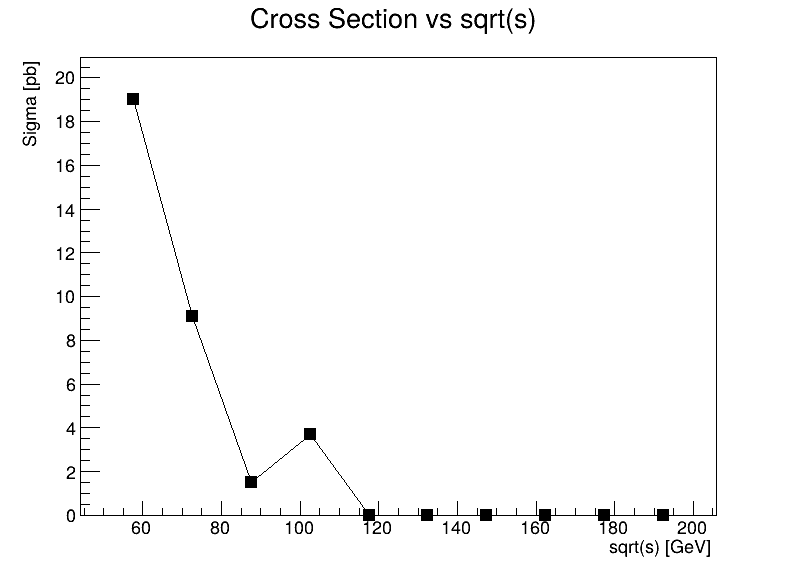

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_K_-.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.31486 GeV/c^2
Mass of 2nd particle = 0.493677 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [44]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_K_-.root");

$\Xi^0 + K^+$

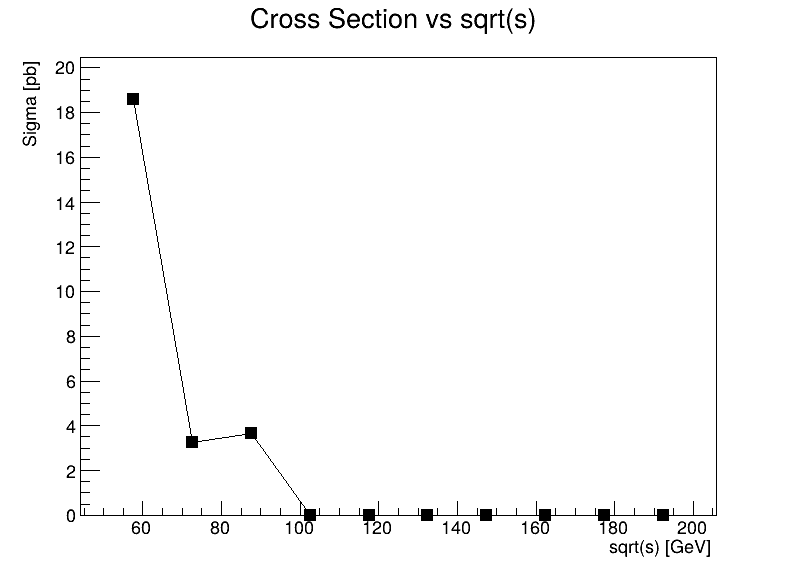

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_K_+.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.31486 GeV/c^2
Mass of 2nd particle = 0.493677 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [45]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_zero_and_K_+.root");

$\Xi^- + \eta$

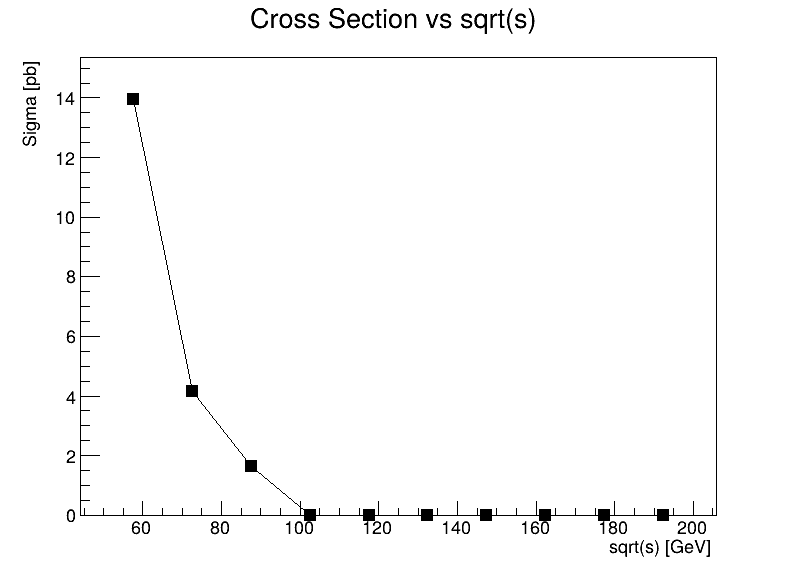

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_eta.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.32171 GeV/c^2
Mass of 2nd particle = 0.547862 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [46]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_eta.root");

$\Xi^- + K^0$

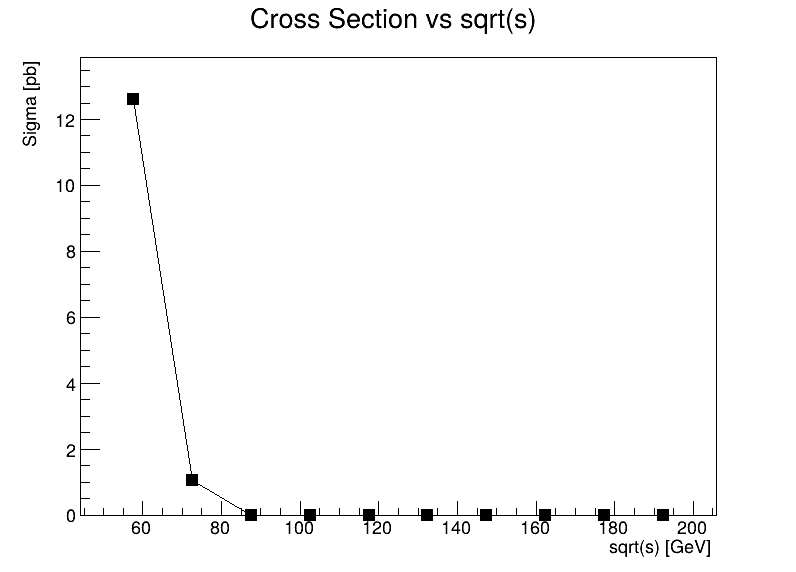

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_K_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.32171 GeV/c^2
Mass of 2nd particle = 0.497611 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [47]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_K_0.root");

$\Xi^- + \bar{K}^0$

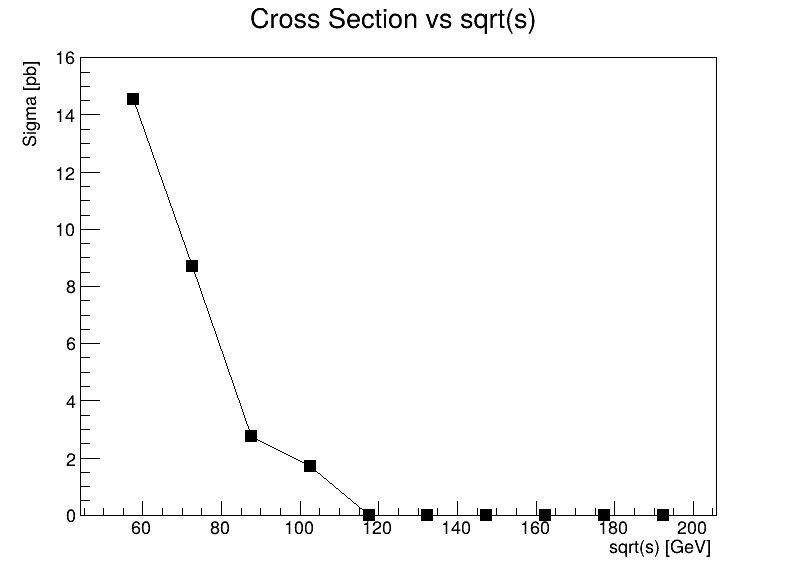

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_K_bar_0.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 1.32171 GeV/c^2
Mass of 2nd particle = 0.497611 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [48]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_xi_minus_and_K_bar_0.root");

$\Omega^{0}_c + \eta$

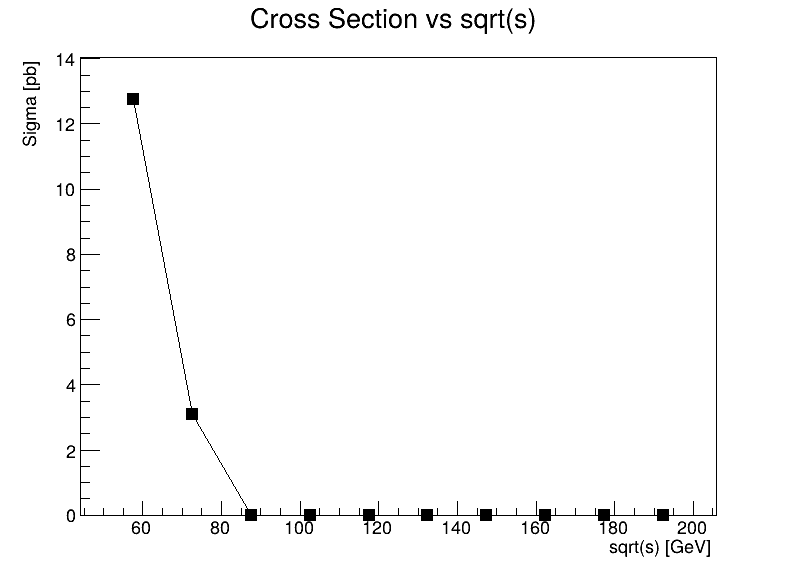

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_eta.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.6952 GeV/c^2
Mass of 2nd particle = 0.547862 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [49]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_eta.root");

$\Omega^{0}_c + D^{-}_s$

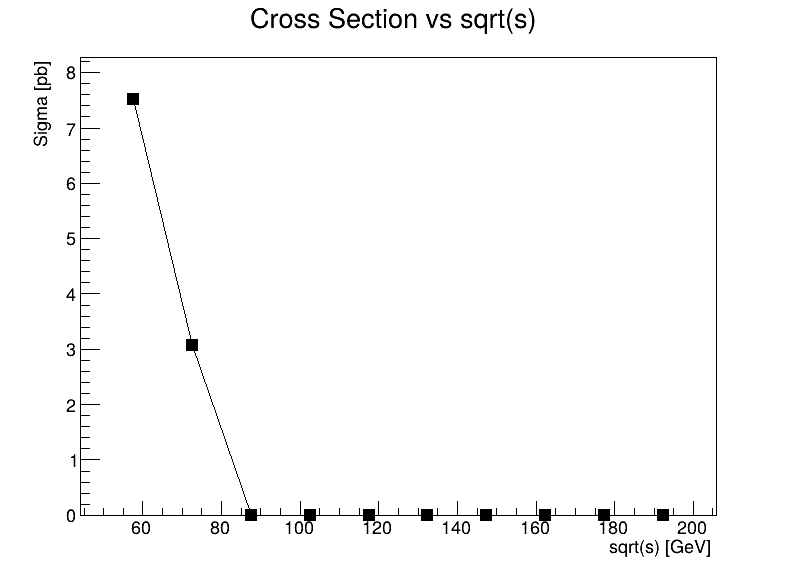

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_D_-_s.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.6952 GeV/c^2
Mass of 2nd particle = 1.96835 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [50]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_D_-_s.root");

$\Omega^{0}_c + D^{+}_s$

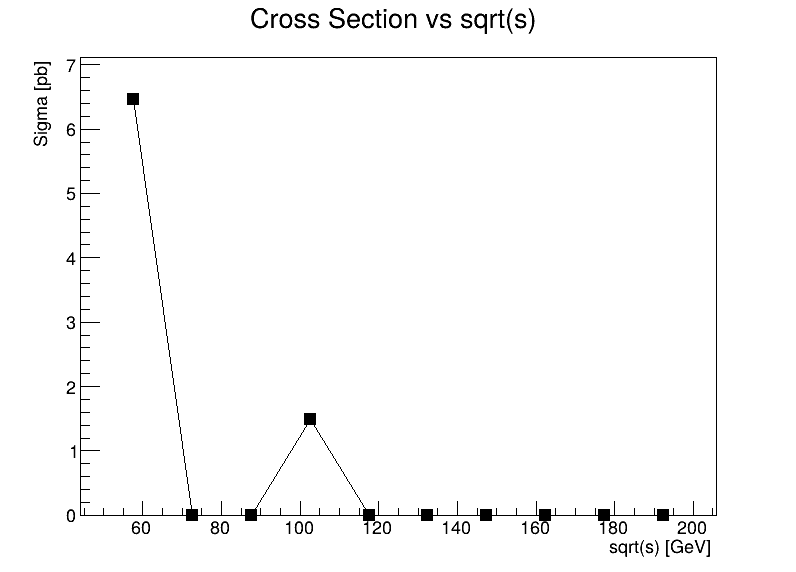

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_D_+_s.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 2.6952 GeV/c^2
Mass of 2nd particle = 1.96835 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [51]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_0_c_and_D_+_s.root");

$\Omega^{-}_b + \eta$

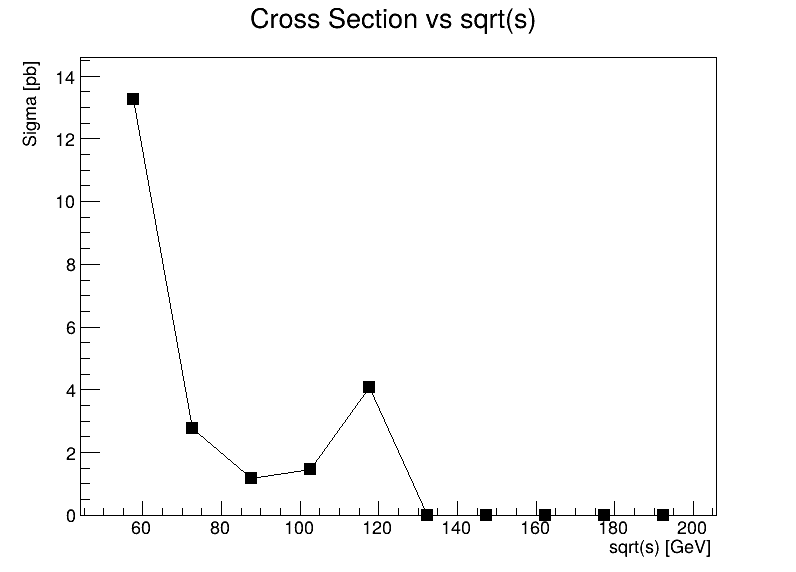

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_eta.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 6.0452 GeV/c^2
Mass of 2nd particle = 0.547862 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [52]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_eta.root");

$\Omega^{-}_b + B^{0}_s$

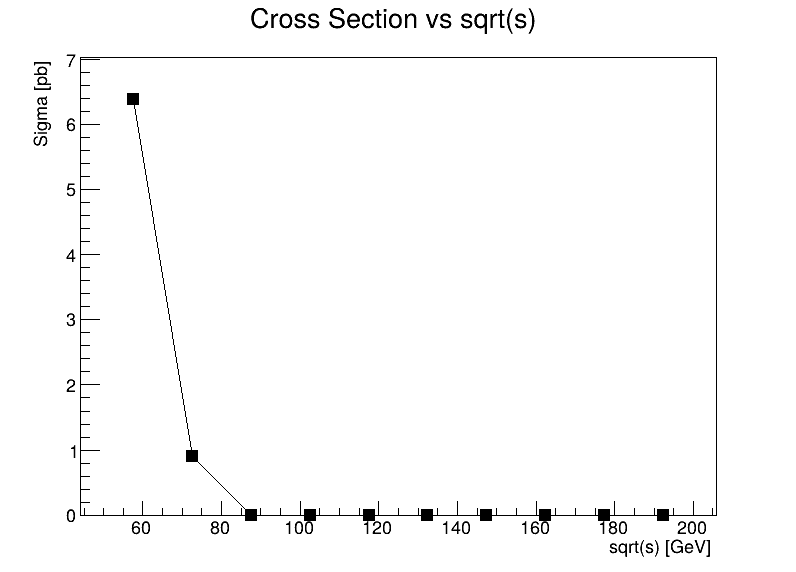

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_B_0_s.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 6.0452 GeV/c^2
Mass of 2nd particle = 5.36692 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [53]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_B_0_s.root");

$\Omega^{-}_b + \bar{B}^{0}_s$

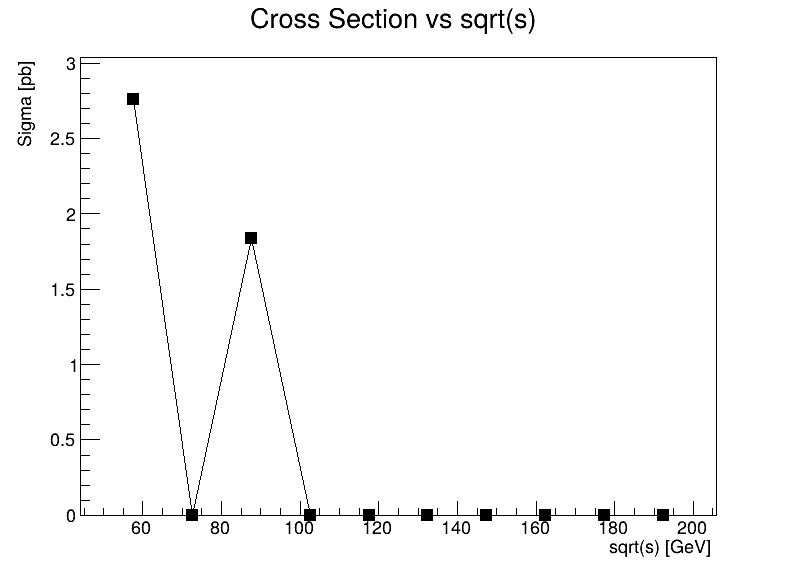

-------------------------------------
reading the file:../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_B_bar_0_s.root
successfully opened the file
successfully opened the tree
Tree has 10000 entries.
-------------------------------------
Mass of 1st particle = 6.0452 GeV/c^2
Mass of 2nd particle = 5.36692 GeV/c^2
successfully filled the histogram with the tree values
successfully computed the cross sections
-------------------------------------
Compton-like Scattering
Compton-like Scattering Plot
-------------------------------------


In [54]:
read_histogram("../PYTHIA_SIMULATION/ROOT_Results/Compton_like/Simulation_omega_minus_b_and_B_bar_0_s.root");

# End